In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers.legacy import Optimizer
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import pickle
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

from time import perf_counter

2025-04-21 12:44:10.066961: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-21 12:44:10.104058: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-21 12:44:10.104178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-21 12:44:10.105236: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-21 12:44:10.111855: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-21 12:44:10.113028: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
counts = pd.read_csv('/work/counts_pred.csv')

X = pd.read_csv('/work/preprocessed.csv')
X['No Of Withdrawals'] = StandardScaler().fit_transform(counts)
y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
y_test_norm = (y_test - y_test.min()) / (y_test.max() - y_test.min())


In [122]:
# hyperparameters for Tube Loss

@keras.utils.register_keras_serializable()
def confidence_loss(y_true, y_pred):

    # Use the Tube loss withq, r and delta parameter.
    
    q = 0.95 # target coverage
    delta = 0.03
    r = 0.25
    
    y_true = y_true[:, 0]
    f2 = y_pred[:, 0]
    f1 = y_pred[:, 1]

    c1 = (1 - q) * (f2 - y_true)
    c2 = (1 - q) * (y_true - f1)
    c3 = q * (f1 - y_true)
    c4 = q * (y_true - f2)

    # Use tf.where to create a tensor based on conditions
    loss_part1 = tf.where(y_true > r * (f1 + f2), c1, c2)
    loss_part2 = tf.where(f1 > y_true, c3, c4)

    final_loss = tf.where(tf.logical_and(y_true <= f2, y_true >= f1), loss_part1, loss_part2) + (delta * tf.abs(f1 - f2))

    # Reduce the loss to a scalar using tf.reduce_mean
    return tf.reduce_mean(final_loss)


In [125]:
def run_ann(X_train, y_train, validation_split):

#set up model call the Tube loss with r=0.1
# n_ = 64 # batch size

    model = Sequential([

            Dense(64, input_dim = X_train.shape[1], activation='relu',
            kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.2),
            kernel_regularizer=l2(1e-2)),

            BatchNormalization(),

            Dense(128, input_dim = X_train.shape[1], activation='relu',
            kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.2),
            kernel_regularizer=l2(1e-2)),
            Dropout(0.3),

            Dense(32, input_dim = X_train.shape[1], activation='relu',
            kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.2),
            kernel_regularizer=l2(1e-2)),

            Dropout(0.3),
            BatchNormalization(),
            
            Dense(2, activation='softplus',
            kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.3),
            bias_initializer=keras.initializers.Constant(value=[-3,3])) # important to init biases to start!
    ])


    opt = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-3)

    model.compile(loss=confidence_loss, optimizer=opt, metrics=['mae'])

    history = model.fit(X_train, y_train, epochs=200, batch_size=32, verbose=1, validation_split=validation_split,)

    return model, history


In [128]:
# Train the ANN with Tube loss
t1 = perf_counter()
model, history = run_ann(X_train, y_train_norm, validation_split=0.1)
t2 = perf_counter()
print(f'Elapsed time: {t2 - t1: .1f} seconds')

Epoch 1/200
286/286 [==============================] - 2s 3ms/step - loss: 4.0804 - mae: 0.8237 - val_loss: 1.3627 - val_mae: 0.2005
Epoch 2/200
286/286 [==============================] - 1s 2ms/step - loss: 0.8949 - mae: 0.2951 - val_loss: 0.4748 - val_mae: 0.3065
Epoch 3/200
286/286 [==============================] - 1s 2ms/step - loss: 0.3056 - mae: 0.2667 - val_loss: 0.1736 - val_mae: 0.2649
Epoch 4/200
286/286 [==============================] - 1s 2ms/step - loss: 0.1217 - mae: 0.2416 - val_loss: 0.0776 - val_mae: 0.2458
Epoch 5/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0579 - mae: 0.2188 - val_loss: 0.0418 - val_mae: 0.2249
Epoch 6/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0371 - mae: 0.2083 - val_loss: 0.0300 - val_mae: 0.2162
Epoch 7/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0299 - mae: 0.2044 - val_loss: 0.0236 - val_mae: 0.1885
Epoch 8/200
286/286 [==============================] - 1s 2ms/step - 

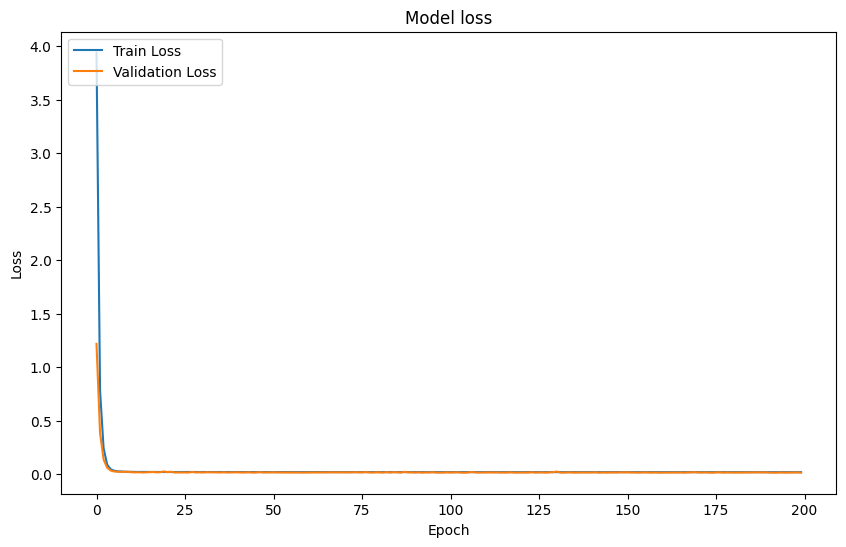

In [98]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Validation Loss'], loc='upper left')
plt.show()

In [129]:
# Train the ANN with Tube loss

model, history = run_ann(X_train, y_train_norm, validation_split=0.0)

Epoch 1/200
317/317 [==============================] - 2s 2ms/step - loss: 3.8614 - mae: 0.8397
Epoch 2/200
317/317 [==============================] - 1s 2ms/step - loss: 0.6526 - mae: 0.3465
Epoch 3/200
317/317 [==============================] - 1s 2ms/step - loss: 0.1782 - mae: 0.2564
Epoch 4/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0638 - mae: 0.2269
Epoch 5/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0357 - mae: 0.2136
Epoch 6/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0286 - mae: 0.2079
Epoch 7/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0255 - mae: 0.1983
Epoch 8/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0243 - mae: 0.1897
Epoch 9/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0229 - mae: 0.1761
Epoch 10/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0228 - mae: 0.1687
Epoch 11/200
317/317 [=================

In [148]:
model.save('TUBE_amt.keras')
model.save('TUBE_amt.h5')

with open('TUBE_amt', 'wb') as file:

    pickle.dump(model, file)

In [131]:
# plot and view some predictions
y_pred = model.predict(X_test, verbose=0)

y_pred_denorm = y_pred * (y_test.max() - y_test.min()) + y_test.min()

ub_amt = y_pred_denorm[:,0].flatten()
lb_amt = y_pred_denorm[:,1].flatten()
mean_pred_amt = (ub_amt + lb_amt) / 2

below_ub = (ub_amt >= y_test).sum() / len(y_test)
print('Points Below Upper Bound:', below_ub)

below_lb = (y_test <= lb_amt).sum() / len(y_test)
print('Points Below Lower Bound:', below_lb)

Points Below Upper Bound: 0.9767258382642998
Points Below Lower Bound: 0.02564102564102564


In [102]:
def compute_picp(y_lower, y_upper, y_true):
    return np.mean(np.logical_and(y_true >= y_lower, y_true <= y_upper))

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def cwc_loss_numpy(y_lower, y_upper, y_true, gamma=50, eta=50, mu=0.95):
    picp = compute_picp(y_lower, y_upper, y_true)
    pinrw = compute_pinrw(y_lower, y_upper, y_true)
    penalty = np.exp(eta * (mu - picp))
    cwc = pinrw * (1 + gamma * penalty)
    mpiw = np.mean(y_upper - y_lower)

    return cwc, picp, mpiw, pinrw

In [139]:
cwc, picp, mpiw, pinrw = cwc_loss_numpy(lb_amt, ub_amt, y_test, gamma=50, eta=50, mu=0.95)

outcome = (y_test > lb_amt) & (y_test < ub_amt)

result = pd.DataFrame({'Original': y_test, 'Predicted': mean_pred_amt,
                        'Lower Bound': lb_amt, 'Upper Bound': ub_amt,
                      'Outcome': outcome})

result.to_csv(f'Results_TUBE_amt.csv', index=False)


In [145]:
cwc, picp, mpiw, pinrw = cwc_loss_numpy(lb_amt, ub_amt, y_test, gamma=50, eta=50, mu=0.95)

outcome = (y_test > lb_amt) & (y_test < ub_amt)

result = pd.DataFrame({'Original': y_test, 'Predicted': mean_pred_amt,
                        'Lower Bound': lb_amt, 'Upper Bound': ub_amt,
                      'Outcome': outcome})

result.to_csv(f'Results_TUBE_amt.csv', index=False)


In [142]:
print('PICP:', picp)
print('CWC:', cwc)
print('PINRW:', pinrw)
print('MPIW:', mpiw)

PICP: 0.9510848126232742
CWC: 14.225578721854758
PINRW: 0.29415876035939936
MPIW: 353795.16


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>